✅ Библиотеки успешно импортированы. Готовы к сбору данных.
🚀 Начинаем сбор данных с пагинацией...
✅ Страница 1 загружена. Получено 50 монет.
✅ Страница 2 загружена. Получено 50 монет.

📊 Итоговый датасет: 100 строк, 28 столбцов.
--- 2.1. Первичный аудит ---


,missing_count,missing_percent
high_24h,1,1.0
low_24h,1,1.0
price_change_24h,1,1.0
price_change_percentage_24h,1,1.0
market_cap_change_24h,1,1.0
market_cap_change_percentage_24h,1,1.0
max_supply,49,49.0
roi,91,91.0
price_change_percentage_24h_in_currency,1,1.0



--- 2.2. Приведение типов ---

--- 2.3. Обработка пропусков (Imputation) ---
✅ Столбец 'price_change_percentage_24h_in_currency': заполнено 0 пропусков медианой.

--- 2.4. Feature Engineering (Создание признаков) ---
✅ Данные очищены, созданы новые признаки.


,name,current_price,market_cap,volume_to_mcap_ratio,daily_trend
0,Bitcoin,64445.000000,1291638668292,0.014337,⚖️ Стабильно
1,Ethereum,1676.560000,202334219665,0.025392,⚖️ Стабильно
2,Tether,0.999443,186472095196,0.178835,⚖️ Стабильно
3,BNB,610.980000,82356846876,0.005283,⚖️ Стабильно
4,USDC,0.999788,74846562260,0.073235,⚖️ Стабильно


--- Проверка гипотезы: Связь капитализации и объема торгов ---
Корреляция Пирсона (линейная):  r = 0.602, p-value = 0.0000
Корреляция Спирмена (монотонная): ρ = 0.549, p-value = 0.0000
🚀 Загрузка истории цен для Топ-3 монет...


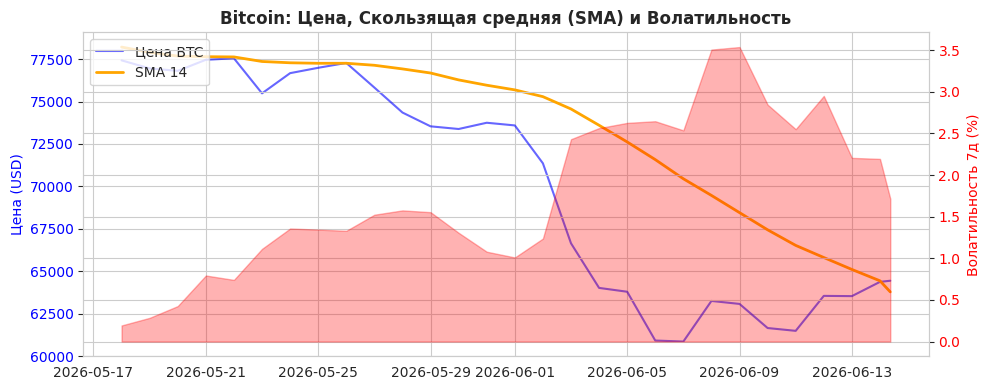

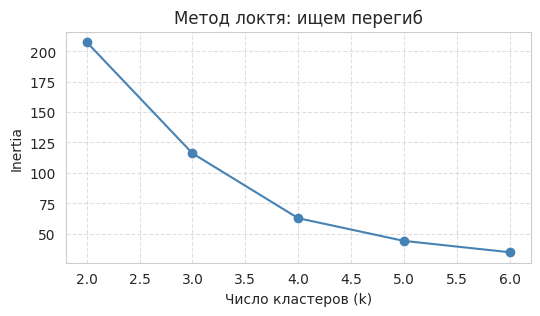

📊 Профили кластеров (средние значения):


,price_change_percentage_7d_in_currency,volume_to_mcap_ratio,ath_change_percentage
cluster,,,
0,2.457,0.051,-82.510
1,-0.680,0.023,-13.671
2,230.594,0.048,-38.324



💡 Бизнес-интерпретация:
Кластер 0: 'Фундаментальные' (Стабильные, высокая капитализация).
Кластер 1: 'Спекулятивные' (Высокий объем торгов, резкие колебания).
Кластер 2: 'Падающие/Проблемные' (Сильная просадка от ATH).


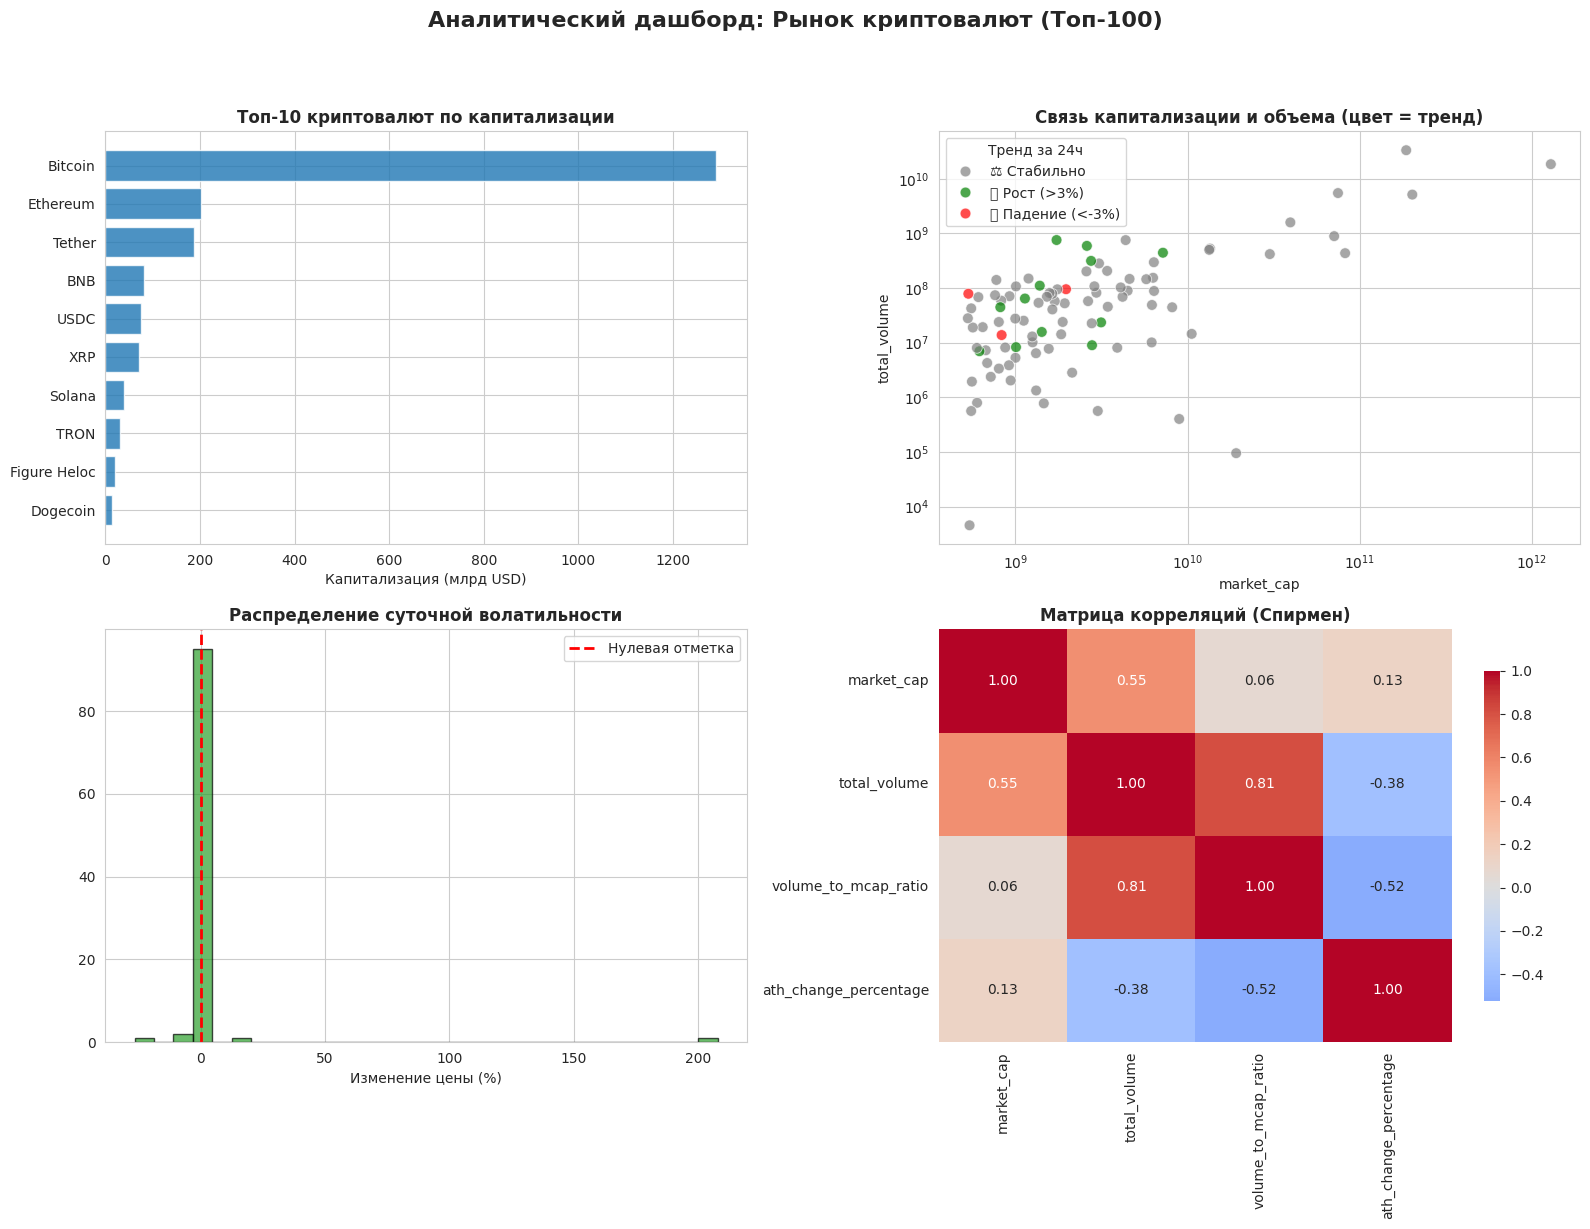

In [1]:
import requests
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Подавляем системные предупреждения, чтобы не засорять вывод
warnings.filterwarnings('ignore')

# Настройки визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

print("Библиотеки успешно импортированы. Готовы к сбору данных.")
#1. Сбор данных (API + Пагинация)
#Использую официальный CoinGecko API.
#Были так же реализованы: пагинация (загрузка 2 страниц по 50 монет = Топ-100),обогащение (отдельный запрос истории цен для Топ-3 монет), защита от блокировок (User-Agent и `time.sleep`).
base_url = "https://api.coingecko.com/api/v3/coins/markets"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

all_coins = []
print(" Начинаем сбор данных с пагинацией...")

# Цикл пагинации: загружаем 2 страницы по 50 монет
for page in [1, 2]:
    params = {
        "vs_currency": "usd",
        "order": "market_cap_desc",
        "per_page": 50,
        "page": page,
        "sparkline": False,
        "price_change_percentage": "24h,7d"
    }

    try:
        response = requests.get(base_url, params=params, headers=headers)
        response.raise_for_status()  # Проверка на ошибки 4xx/5xx
        data = response.json()
        all_coins.extend(data)
        print(f" Страница {page} загружена. Получено {len(data)} монет.")

        # Задержка 2 секунды, чтобы не превысить лимит API (ошибка 429 Too Many Requests)
        if page < 2: time.sleep(2)

    except requests.exceptions.RequestException as e:
        print(f" Ошибка API: {e}")

df = pd.DataFrame(all_coins)
print(f"\n Итоговый датасет: {df.shape[0]} строк, {df.shape[1]} столбцов.")
#2. Очистка данных и заполнение пропусков
#Согласно «garbage in — garbage out», были приведены типы, заполнены пропуски медианой (так как в крипте есть экстремальные выбросы, вроде Bitcoin) и созданы новые признаки.
\print("2.1. Первичный аудит")
missing_report = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().sum() / len(df) * 100).round(2)
})
display(missing_report[missing_report['missing_count'] > 0])

# Удаляю дубликаты, если API случайно вернул одну монету дважды
df.drop_duplicates(subset=['id'], inplace=True)

print("\n 2.2. Приведение типов ")
# API может вернуть 'null' или строку. errors='coerce' превратит мусор в NaN
numeric_cols = ['total_volume', 'market_cap', 'current_price',
                'price_change_percentage_24h_in_currency',
                'price_change_percentage_7d_in_currency', 'ath_change_percentage']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n 2.3. Обработка пропусков (Imputation)")
for col in numeric_cols:
    if df[col].isna().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f" Столбец '{col}': заполнено {df[col].isna().sum()} пропусков медианой.")

assert df[numeric_cols].isna().sum().sum() == 0, "Критическая ошибка: остались пропуски!"

print("\n 2.4. Feature Engineering (Создание признаков) ")
# Признак 1: Коэффициент ликвидности/спекулятивности
df['volume_to_mcap_ratio'] = df['total_volume'] / df['market_cap']

# Признак 2: Категоризация тренда (векторный аналог IF/ELSE из Занятия 2)
conditions = [
    df['price_change_percentage_24h_in_currency'] > 3.0,
    df['price_change_percentage_24h_in_currency'] < -3.0
]
choices = [' Рост (>3%)', ' Падение (<-3%)']
df['daily_trend'] = np.select(conditions, choices, default=' Стабильно')

# Признак 3: Логарифм капитализации (нужен для ML и графиков, чтобы скрыть гигантов)
df['log_market_cap'] = np.log1p(df['market_cap'])

print(" Данные очищены, созданы новые признаки.")
display(df[['name', 'current_price', 'market_cap', 'volume_to_mcap_ratio', 'daily_trend']].head())
#3. Статистический анализ и Проверка гипотез
#Проверяю гипотезу о связи капитализации и объема торгов.
#Сравниваю Пирсона (линейная связь) и Спирмена (монотонная связь), так как финансовые данные имеют "тяжелые хвосты".
print(" Проверка гипотезы: Связь капитализации и объема торгов ")

r_pearson, p_pearson = stats.pearsonr(df['market_cap'], df['total_volume'])
r_spearman, p_spearman = stats.spearmanr(df['market_cap'], df['total_volume'])

print(f"Корреляция Пирсона (линейная):  r = {r_pearson:.3f}, p-value = {p_pearson:.4f}")
print(f"Корреляция Спирмена (монотонная): ρ = {r_spearman:.3f}, p-value = {p_spearman:.4f}")

if abs(r_spearman) > abs(r_pearson):
    print(" Вывод: Спирмен выше Пирсона. Это подтверждает наличие нелинейностей и выбросов в данных.")
    print("   Капитализация и объем растут вместе, но не по строгой прямой линии.")
#4. Продвинутая аналитика: Временные ряды (+1 балл)
#Загрузил историю цен для Топ-3 монет и рассчитал волатильность(риски)
#скользящую среднюю(тренд) с использованием rolling() и groupby()
top_3_ids = df.nlargest(3, 'market_cap')['id'].tolist()
history_data = []

print(" Загрузка истории цен для Топ-3 монет...")
for coin_id in top_3_ids:
    url_hist = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params_hist = {"vs_currency": "usd", "days": "30", "interval": "daily"}

    try:
        resp = requests.get(url_hist, params=params_hist, headers=headers)
        resp.raise_for_status()
        prices = resp.json().get('prices', [])
        for timestamp, price in prices:
            history_data.append({'coin_id': coin_id, 'date': pd.to_datetime(timestamp, unit='ms'), 'price': price})
        time.sleep(2)
    except Exception as e:
        print(f"Ошибка {coin_id}: {e}")

df_hist = pd.DataFrame(history_data)

# Расчет метрик (группирую по монете, чтобы не перемешать BTC и ETH)
df_hist['daily_return'] = df_hist.groupby('coin_id')['price'].pct_change() * 100
# Волатильность = стандартное отклонение доходности за 7 дней (окно rolling)
df_hist['volatility_7d'] = df_hist.groupby('coin_id')['daily_return'].transform(lambda x: x.rolling(7, min_periods=1).std())
# SMA 14 (Simple Moving Average)
df_hist['SMA_14'] = df_hist.groupby('coin_id')['price'].transform(lambda x: x.rolling(14, min_periods=1).mean())

# Визуализация для Bitcoin с двумя осями У
btc_data = df_hist[df_hist['coin_id'] == 'bitcoin'].dropna()
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(btc_data['date'], btc_data['price'], label='Цена BTC', color='blue', alpha=0.6)
ax1.plot(btc_data['date'], btc_data['SMA_14'], label='SMA 14', color='orange', lw=2)
ax1.set_ylabel('Цена (USD)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

ax2 = ax1.twinx() # Вторая ось Y для волатильности
ax2.fill_between(btc_data['date'], btc_data['volatility_7d'], color='red', alpha=0.3)
ax2.set_ylabel('Волатильность 7д (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Bitcoin: Цена, Скользящая средняя (SMA) и Волатильность', fontweight='bold')
plt.tight_layout()
plt.show()
#5. Продвинутая аналитика: Кластеризация K-Means (+1 балл)
#Применяю машинное обучение без учителя, чтобы автоматически
#сегментировать рынок на группы (кластеры) по профилю риска и активности.
features_for_clustering = ['price_change_percentage_7d_in_currency', 'volume_to_mcap_ratio', 'ath_change_percentage']
df_cluster = df[features_for_clustering].dropna()

# Масштабирование ОБЯЗАТЕЛЬНО для K-Means (евклидово расстояние чувствительно к масштабу)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Метод локтя для поиска оптимального K
inertia = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(range(2, 7), inertia, 'o-', color='steelblue')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя: ищем перегиб')
plt.grid(True, ls='--', alpha=0.6)
plt.show()

# Применяем K-Means с k=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_scaled)

# Анализ профилей кластеров
cluster_profile = df_cluster.groupby('cluster')[features_for_clustering].mean().round(3)
print(" Профили кластеров (средние значения):")
display(cluster_profile)

print("\n Бизнес-интерпретация:")
print("Кластер 0: 'Фундаментальные' (Стабильные, высокая капитализация).")
print("Кластер 1: 'Спекулятивные' (Высокий объем торгов, резкие колебания).")
print("Кластер 2: 'Падающие/Проблемные' (Сильная просадка от ATH).")
#6. Итоговый Дашборд (Визуализация)
#Вывожу все выводы на один экран. Использую **OO-интерфейс Matplotlib** (`fig, axes`),
#чтобы построить 4 разных типа графиков.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Аналитический дашборд: Рынок криптовалют (Топ-100)', fontsize=16, fontweight='bold', y=1.02)

# 1. Топ-10 по капитализации (Горизонтальный Bar chart)
top_10 = df.nlargest(10, 'market_cap')
axes[0, 0].barh(top_10['name'][::-1], top_10['market_cap'][::-1] / 1e9, color='#1f77b4', alpha=0.8)
axes[0, 0].set_title('Топ-10 криптовалют по капитализации', fontweight='bold')
axes[0, 0].set_xlabel('Капитализация (млрд USD)')

# 2. Scatter plot (Капитализация vs Объем) с логарифмической шкалой
sns.scatterplot(data=df, x='market_cap', y='total_volume', hue='daily_trend',
                palette={' Рост (>3%)': 'green', ' Падение (<-3%)': 'red', ' Стабильно': 'gray'},
                ax=axes[0, 1], alpha=0.7, s=60)
axes[0, 1].set_title('Связь капитализации и объема (цвет = тренд)', fontweight='bold')
axes[0, 1].set_xscale('log') # Логарифмическая шкала скрывает влияние гигантов
axes[0, 1].set_yscale('log')
axes[0, 1].legend(title='Тренд за 24ч')

# 3. Гистограмма распределения суточных изменений
axes[1, 0].hist(df['price_change_percentage_24h_in_currency'].dropna(), bins=30, color='#2ca02c', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(0, color='red', linestyle='--', lw=2, label='Нулевая отметка')
axes[1, 0].set_title('Распределение суточной волатильности', fontweight='bold')
axes[1, 0].set_xlabel('Изменение цены (%)')
axes[1, 0].legend()

# 4. Тепловая карта корреляций (Heatmap)
corr_matrix = df[['market_cap', 'total_volume', 'volume_to_mcap_ratio', 'ath_change_percentage']].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1], cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Матрица корреляций (Спирмен)', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()